In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import json
from pathlib import Path

# Load data eksperimen
df = pd.read_csv('../results/cnn/experiment_cnn.csv')

df['filters']     = df['filters'].apply(eval)
df['kernel_size'] = df['kernel_size'].apply(eval)

df['label'] = df.apply(
    lambda r: f"L{r['num_conv_layers']} F{r['filters']} K{r['kernel_size']} {r['pooling_type'][:3]}",
    axis=1
)

# Load history per model  
history_dir = Path('../results/cnn')

def load_history(model_name):
    path = history_dir / f"{model_name}_history.json"
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None

df['history'] = df['model_name'].apply(load_history)

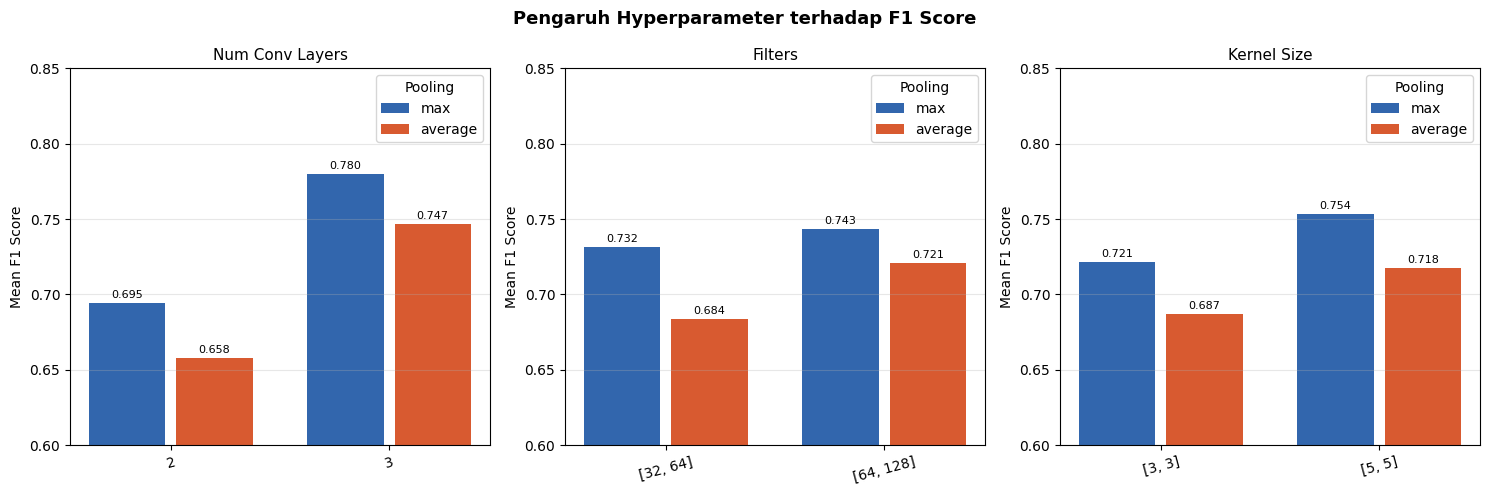

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Pengaruh Hyperparameter terhadap F1 Score', fontsize=13, fontweight='bold')

hparams = [
    ('num_conv_layers', 'Num Conv Layers'),
    ('filters_str',     'Filters'),
    ('kernel_str',      'Kernel Size'),
]

df['filters_str'] = df['filters'].astype(str)
df['kernel_str']  = df['kernel_size'].astype(str)

pooling_types = df['pooling_type'].unique()
x_offset = np.array([-0.2, 0.2])
colors = {'max': '#3266ad', 'average': '#d85a30'}

for ax, (col, title) in zip(axes, hparams):
    categories = df[col].unique()
    x = np.arange(len(categories))

    for i, pooling in enumerate(pooling_types):
        means = (df[df['pooling_type'] == pooling]
                   .groupby(col)['f1_macro']
                   .mean()
                   .reindex(categories))
        bars = ax.bar(x + x_offset[i], means, width=0.35,
                      label=pooling, color=colors[pooling], edgecolor='none')
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=15)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Mean F1 Score')
    ax.set_ylim(0.6, 0.85)
    ax.legend(title='Pooling')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

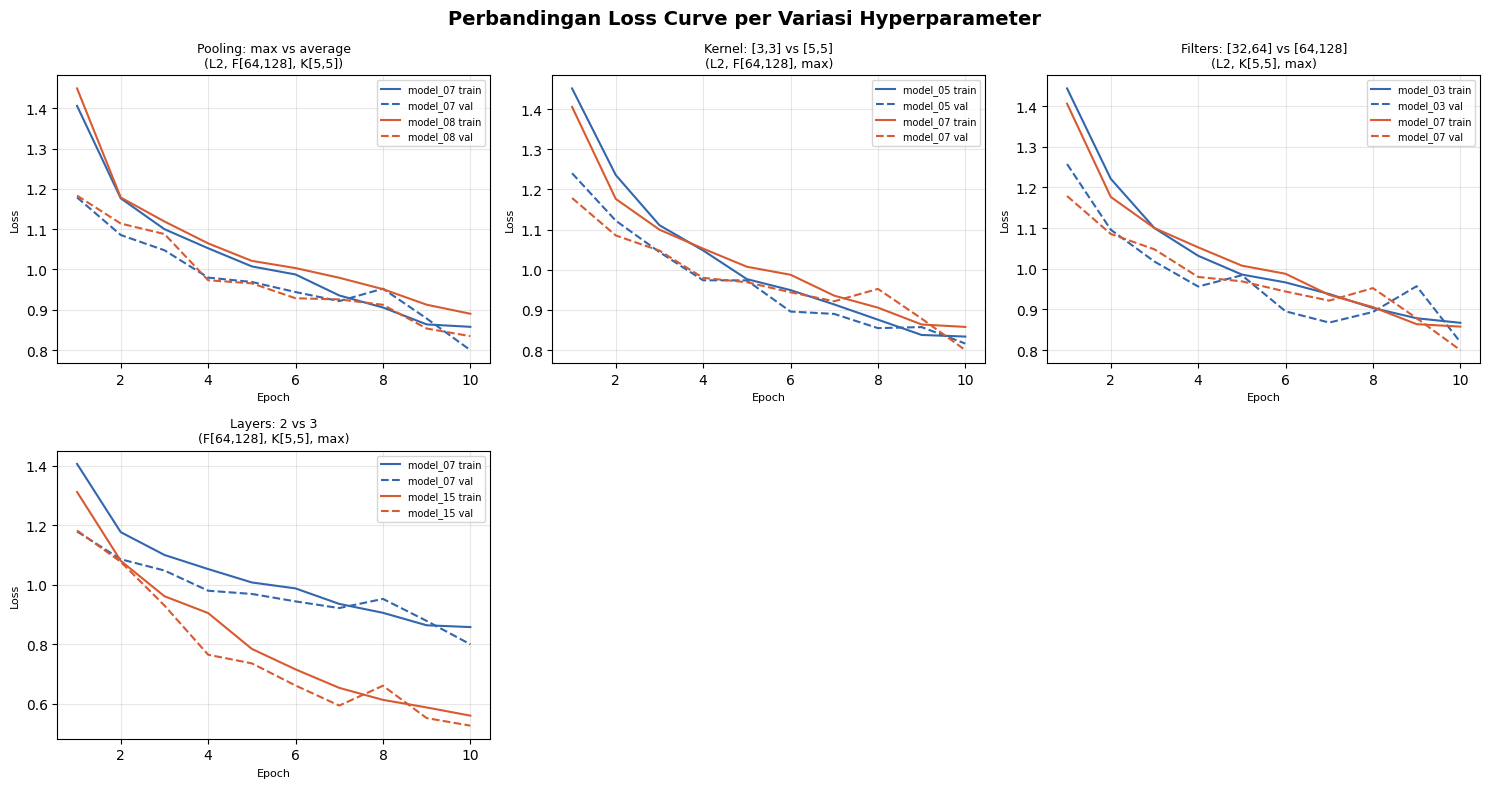

In [ ]:
comparisons = [
    # Pooling type (max vs average)
    ('model_07', 'model_08', 'Pooling: max vs average\n(L2, F[64,128], K[5,5])'),

    # Kernel size ([3,3] vs [5,5])
    ('model_05', 'model_07', 'Kernel: [3,3] vs [5,5]\n(L2, F[64,128], max)'),

    # Filters ([32,64] vs [64,128])
    ('model_03', 'model_07', 'Filters: [32,64] vs [64,128]\n(L2, K[5,5], max)'),

    # Num conv layers (2 vs 3)
    ('model_07', 'model_15', 'Layers: 2 vs 3\n(F[64,128], K[5,5], max)'),
]

ncols = 3
nrows = int(np.ceil(len(comparisons) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
fig.suptitle('Perbandingan Loss Curve per Variasi Hyperparameter', fontsize=14, fontweight='bold')
axes = axes.flatten()

history_map = dict(zip(df['model_name'], df['history']))

for i, (m_a, m_b, title) in enumerate(comparisons):
    ax = axes[i]
    h_a = history_map.get(m_a)
    h_b = history_map.get(m_b)

    if h_a:
        epochs = range(1, len(h_a['loss']) + 1)
        ax.plot(epochs, h_a['loss'],     color='#3266ad', linestyle='-',  label=f'{m_a} train')
        ax.plot(epochs, h_a['val_loss'], color='#3266ad', linestyle='--', label=f'{m_a} val')
    if h_b:
        epochs = range(1, len(h_b['loss']) + 1)
        ax.plot(epochs, h_b['loss'],     color='#d85a30', linestyle='-',  label=f'{m_b} train')
        ax.plot(epochs, h_b['val_loss'], color='#d85a30', linestyle='--', label=f'{m_b} val')

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('Loss', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()